In [1]:
# --- All imports collected and organized at the top ---
# Core scientific libraries
import os 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # Disable XLA preallocation to prevent OOM errors
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"  # Limit XLA to use at most 80% of GPU memory

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm
from scipy.ndimage import gaussian_filter

import jax 

# Pyramid core imports
import pyramid as pr
from pyramid.magcreator.shapes import disc
from pyramid.magcreator.magcreator import create_mag_dist_homog
from pyramid.fielddata import VectorData
from pyramid.projector import SimpleProjector
from pyramid.phasemapper import PhaseMapperFDFC, PhaseMapperRDFC
from pyramid.dataset import DataSet
from pyramid.forwardmodel import ForwardModel
from pyramid.diagnostics import LCurve
from pyramid.utils.convenience import reconstruction_2d_from_phasemap
from pyramid.phasemap import PhaseMap
from pyramid.kernel import Kernel

# LiberTEM-holo MBIR imports
from libertem_holo.base.mbir import (
    forward_model_2d,
    lcurve_sweep_vmap,
    reconstruct_2d,
 )

jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision in JAX

# Synthetic Magnetisation Reconstruction with Pyramid
This notebook demonstrates the workflow for generating a synthetic magnetisation distribution, simulating phase maps, and reconstructing the magnetisation using the Pyramid library.

---


In [2]:
N = 128
dim = (N, N, N)
center = (N//2, N//2, N//2)
R = 40
H = 10
px_size = 1
mag_shape = disc(dim=dim, center=center, radius=R, height=H)
disc_uni = create_mag_dist_homog(mag_shape=mag_shape, phi=np.pi/2)

## 1. Create Synthetic Magnetisation Distribution
We define a synthetic disc-shaped magnetisation distribution for testing.

In [3]:
mag_distrib = VectorData(a=1, field=disc_uni)

### Visualize Magnetisation Components
Display the three components of the synthetic magnetisation in the central slice.

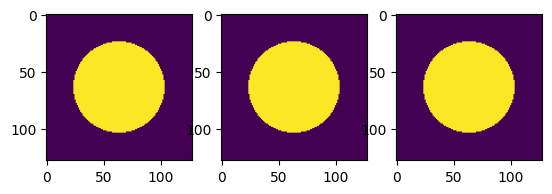

In [4]:
fig, ax = plt.subplots(ncols=3)

ax[0].imshow(mag_distrib.field[0, N//2, ...])
ax[1].imshow(mag_distrib.field[1, N//2, ...])
ax[2].imshow(mag_distrib.field[2, N//2, ...])

In [5]:
b_0 = 1.25
projector = SimpleProjector(mag_distrib.dim, axis='z')
kern = Kernel(mag_distrib.a, projector.dim_uv, b_0=b_0, geometry="disc")
phasemapper = PhaseMapperRDFC(kern)
field_proj = projector(mag_distrib)
phasemap = phasemapper(field_proj)
phasemap.mask = field_proj.get_mask()[0, ...]

## 2. Simulate Phase Map
Project the synthetic magnetisation and simulate the phase map using the forward model.

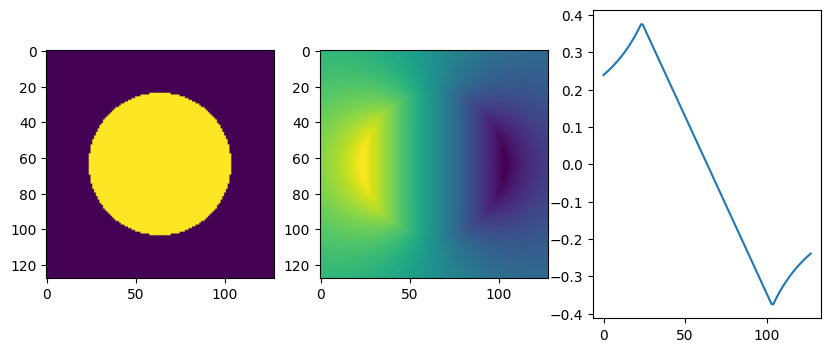

In [6]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))
ax[0].imshow(phasemap.mask)
ax[1].imshow(phasemap.phase)
ax[2].plot(phasemap.phase[N//2, ...])

### Visualize Phase Map and Mask
Show the simulated phase map and the mask used for further processing.

In [7]:
phase_mag = phasemap.phase
phase_mip = phasemap.mask

Mask covers 5024 / 16384 pixels (30.7%)


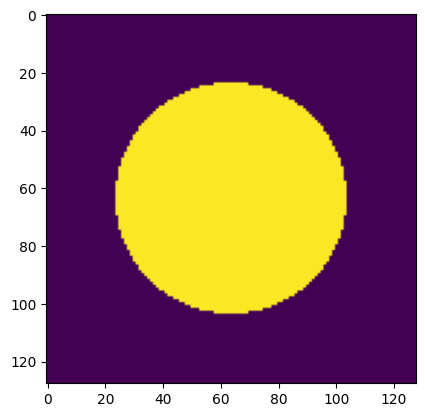

In [8]:
mip_threshold = 0.1
mask = (np.abs(phase_mip) > mip_threshold).astype(np.float64)
plt.figure()
plt.imshow(mask)
print(f"Mask covers {mask.sum():.0f} / {mask.size} pixels "
      f"({100 * mask.mean():.1f}%)")

phasemap = pr.PhaseMap(a=px_size, phase=phase_mag, mask=mask)
dim = (1,) + phasemap.dim_uv
data_set = pr.DataSet(phasemap.a, dim=dim, b_0=b_0)

# Pass a PhaseMapperRDFC explicitly so Pyramid's ForwardModel uses the same
# forward model as MBIR (zero-padded linear convolution, not periodic FDFC).
kern_pyr_rdfc = Kernel(px_size, phasemap.dim_uv, b_0=b_0, geometry="disc")
phasemapper_rdfc = PhaseMapperRDFC(kern_pyr_rdfc)
data_set.append(phasemap, pr.SimpleProjector(dim=dim), phasemapper=phasemapper_rdfc)

## 3. Prepare Data for Reconstruction
Apply a mask to the phase map and prepare the dataset for the forward model.

In [9]:
ramp_order = 1
fwd_model = pr.ForwardModel(data_set, ramp_order=ramp_order)

## 4. Forward Model and L-Curve Analysis
Set up the forward model and perform L-curve analysis to select the regularization parameter.

  0%|          | 0/10 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

<Axes: xlabel='$\\Vert\\mathbf{F}(\\mathbf{x})-\\mathbf{y}\\Vert_{\\mathbf{S}_{\\epsilon}^{-1}}^{2}$', ylabel='$\\frac{1}{\\lambda}\\Vert\\mathbf{x}\\Vert_{\\mathbf{S}_{a}^{-1}}^{2}$'>

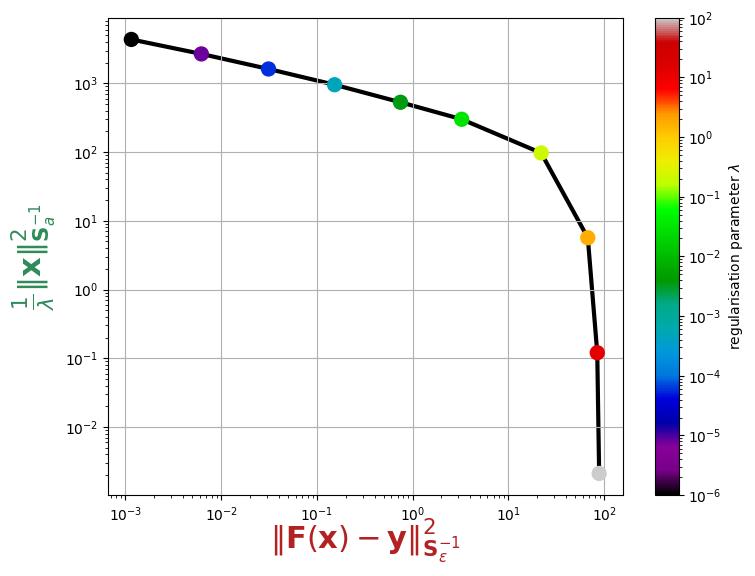

In [24]:
lambdas = np.logspace(-6, 2, num=10)
max_iter = 1000

lcurve = pr.LCurve(fwd_model, max_iter=max_iter, save_dir='MBIR/lcurve_synthetic')
lcurve.calculate(lambdas)
lcurve.plot(lambdas)

In [11]:
# (imports moved to top)

## 5. 2D Reconstruction from Phase Map
Use the selected regularization parameter to reconstruct the 2D magnetisation distribution from the phase map.

In [25]:
voxel_size_nm = 1
b0_tesla = b_0
best_lam = 10e1

In [26]:
# (imports moved to top)

pm = PhaseMap(a=voxel_size_nm, phase=np.asarray(phase_mag), mask=mask)
magdata_pyr, cost_pyr = reconstruction_2d_from_phasemap(
    pm, b_0=b0_tesla, lam=float(best_lam), max_iter=1000,
    ramp_order=None, verbose=True,
    )

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

In [27]:
u_pyr = magdata_pyr.field[0,0,...]
v_pyr = magdata_pyr.field[1,0,...]
mag_abs_pyr = magdata_pyr.field_amp[0,...]
#u_pyr.shape, v_pyr.shape, mag_abs_pyr.shape


### Extract Magnetisation Components
Extract the reconstructed $M_x$, $M_y$, and $|M|$ components from the result.

### Normalization Check for Pyramid Reconstruction
To ensure Pyramid's reconstructed magnetization is correctly normalized, the following points are critical:
- The synthetic phase and the reconstruction must use the same forward model (e.g., both RDFC).
- The mask must cover the full region of nonzero magnetization.
- The expected projected $|M|$ is the sum of per-voxel $|M|$ along the projection axis (e.g., height $H$ for a disc with $|M|=1$ per voxel).
- All physical parameters (voxel size, $b_0$, etc.) must be consistent.

The next cell prints the mean and max $|M|$ inside the mask and compares to the expected value.

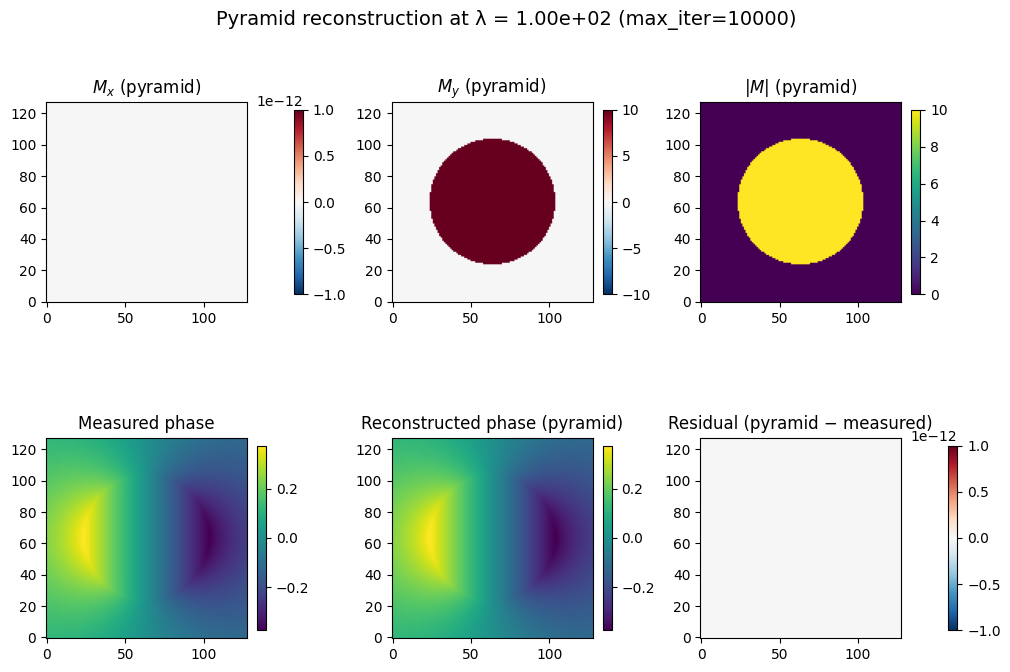

Pyramid residual RMS: 0.000000


In [28]:
# Pyramid result: same 2×3 layout as libertem_holo

# Forward-model pyramid's reconstruction to get predicted phase
kern_pyr = Kernel(voxel_size_nm, phase_mag.shape, b_0=b0_tesla, geometry="disc")
mapper_pyr = PhaseMapperRDFC(kern_pyr)
field_pyr = np.zeros((3, 1) + phase_mag.shape)
field_pyr[0, 0] = u_pyr
field_pyr[1, 0] = v_pyr
pred_pyr = mapper_pyr(VectorData(voxel_size_nm, field_pyr)).phase
residual_pyr = pred_pyr - phase_mag

fig, axs = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)

# Row 1: magnetisation components

vmax_u = max(np.abs(u_pyr).max(), 1e-12)
vmax_v = max(np.abs(v_pyr).max(), 1e-12)

im = axs[0, 0].imshow(u_pyr, cmap="RdBu_r", origin="lower",
                        norm=TwoSlopeNorm(0, -vmax_u, vmax_u))
axs[0, 0].set_title(r"$M_x$ (pyramid)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(v_pyr, cmap="RdBu_r", origin="lower",
                        norm=TwoSlopeNorm(0, -vmax_v, vmax_v))
axs[0, 1].set_title(r"$M_y$ (pyramid)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(mag_abs_pyr, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (pyramid)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

# Row 2: phase comparison
vmin_p = min(np.nanmin(phase_mag), np.nanmin(pred_pyr))
vmax_p = max(np.nanmax(phase_mag), np.nanmax(pred_pyr))

im = axs[1, 0].imshow(phase_mag, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(pred_pyr, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 1].set_title("Reconstructed phase (pyramid)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

dmax_p = max(np.abs(residual_pyr).max(), 1e-12)
im = axs[1, 2].imshow(residual_pyr, cmap="RdBu_r", origin="lower", vmin=-dmax_p, vmax=dmax_p)
axs[1, 2].set_title("Residual (pyramid − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(f"Pyramid reconstruction at λ = {best_lam:.2e} (max_iter=10000)", fontsize=14)
plt.show()

print(f"Pyramid residual RMS: {np.sqrt(np.mean(residual_pyr**2)):.6f}")
#print(f"LT-holo residual RMS: {np.sqrt(np.mean((np.asarray(pred_phase) - mag_phase)**2)):.6f}")

In [29]:
# --- Diagnostic: Check Pyramid normalization ---
inside = mask > 0.5
print(f"True per-voxel |M| = 1.0")
print(f"True projected |M| = H = {H} (sum of {H} voxels along z)")
print()
print("--- Pyramid reconstruction normalization ---")
print(f"Pyramid |M| mean inside mask: {mag_abs_pyr[inside].mean():.4f}")
print(f"Pyramid |M| max inside mask:  {mag_abs_pyr[inside].max():.4f}")
print(f"Expected projected |M| = {H}")
print(f"Per-voxel |M| = |M|_proj / H = {mag_abs_pyr[inside].mean() / H:.4f} (expected 1.0)")

True per-voxel |M| = 1.0
True projected |M| = H = 10 (sum of 10 voxels along z)

--- Pyramid reconstruction normalization ---
Pyramid |M| mean inside mask: 10.0000
Pyramid |M| max inside mask:  10.0000
Expected projected |M| = 10
Per-voxel |M| = |M|_proj / H = 1.0000 (expected 1.0)


## 7. MBIR Solution with LiberTEM-holo
Now we reconstruct the magnetisation using the MBIR method from `libertem_holo.base.mbir` and compare it to the Pyramid solution.

In [33]:
# --- MBIR L-curve analysis using LiberTEM-holo ---
# Use the same synthetic phase and mask as for Pyramid

lambdas_mbir = np.logspace(-6, 2, num=20)
lc_mbir = lcurve_sweep_vmap(
    phase=phase_mag,
    mask=mask,
    voxel_size_nm=voxel_size_nm,
    lambdas=lambdas_mbir,
    b0_tesla=b0_tesla,
    solver="newton_cg",
)

import jax
jax.block_until_ready(lc_mbir.magnetizations)

print(f"MBIR L-curve corner: index {lc_mbir.corner_index} (lambda = {lc_mbir.lambdas[lc_mbir.corner_index]:.3e})")

MBIR L-curve corner: index 11 (lambda = 4.281e-02)


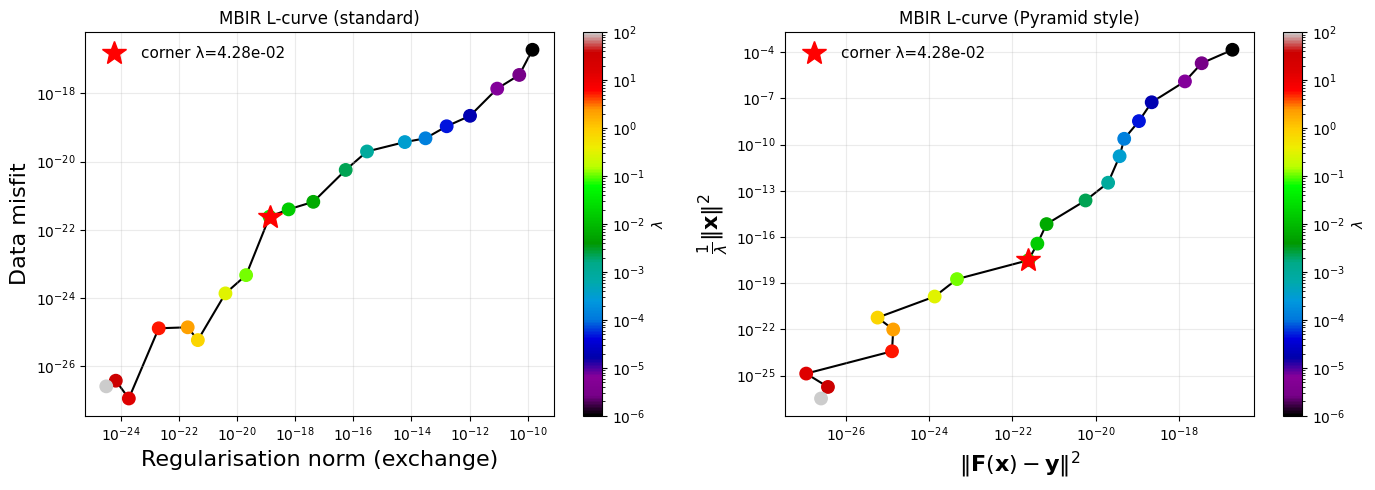

In [34]:
# --- Plot MBIR L-curve (standard and Pyramid style) ---
from libertem_holo.base import mbir as mbir_mod
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
mbir_mod.plot_lcurve(lc_mbir, pyramid_style=False, ax=axs[0])
axs[0].set_title("MBIR L-curve (standard)")
mbir_mod.plot_lcurve(lc_mbir, pyramid_style=True, ax=axs[1])
axs[1].set_title("MBIR L-curve (Pyramid style)")
plt.tight_layout()
plt.show()

In [35]:
# --- Final MBIR reconstruction at optimal lambda ---
best_lam_mbir = lc_mbir.lambdas[lc_mbir.corner_index]

result_mbir = reconstruct_2d(
    phase=phase_mag,
    voxel_size_nm=voxel_size_nm,
    b0_tesla=b0_tesla,
    mask=mask,
    lam=best_lam_mbir,
    solver="newton_cg",
    thickness=H,  # divide by thickness → per-voxel magnetization
)

best_mag_mbir = result_mbir.magnetization
best_ramp_mbir = result_mbir.ramp_coeffs

# Forward-model the best MBIR reconstruction to get the predicted phase
# (thickness= H converts per-voxel M back to projected before forward model)
pred_phase_mbir = forward_model_2d(
    best_mag_mbir, voxel_size_nm,
    b0_tesla=b0_tesla, ramp_coeffs=best_ramp_mbir,
    thickness=H,
)

print(f"Best MBIR lambda: {best_lam_mbir:.3e}")
print(f"Final MBIR loss:  {float(result_mbir.loss_history[-1]):.3e}")
print()
inside = mask > 0.5
mag_norm_mbir = np.sqrt(
    np.asarray(best_mag_mbir[..., 0])**2 + np.asarray(best_mag_mbir[..., 1])**2
)
print(f"Per-voxel |M| mean inside mask: {mag_norm_mbir[inside].mean():.4f}  (expected ≈ 1.0)")
print(f"Per-voxel |M| max inside mask:  {mag_norm_mbir[inside].max():.4f}")

Best MBIR lambda: 4.281e-02
Final MBIR loss:  8.459e-21

Per-voxel |M| mean inside mask: 1.0000  (expected ≈ 1.0)
Per-voxel |M| max inside mask:  1.0000


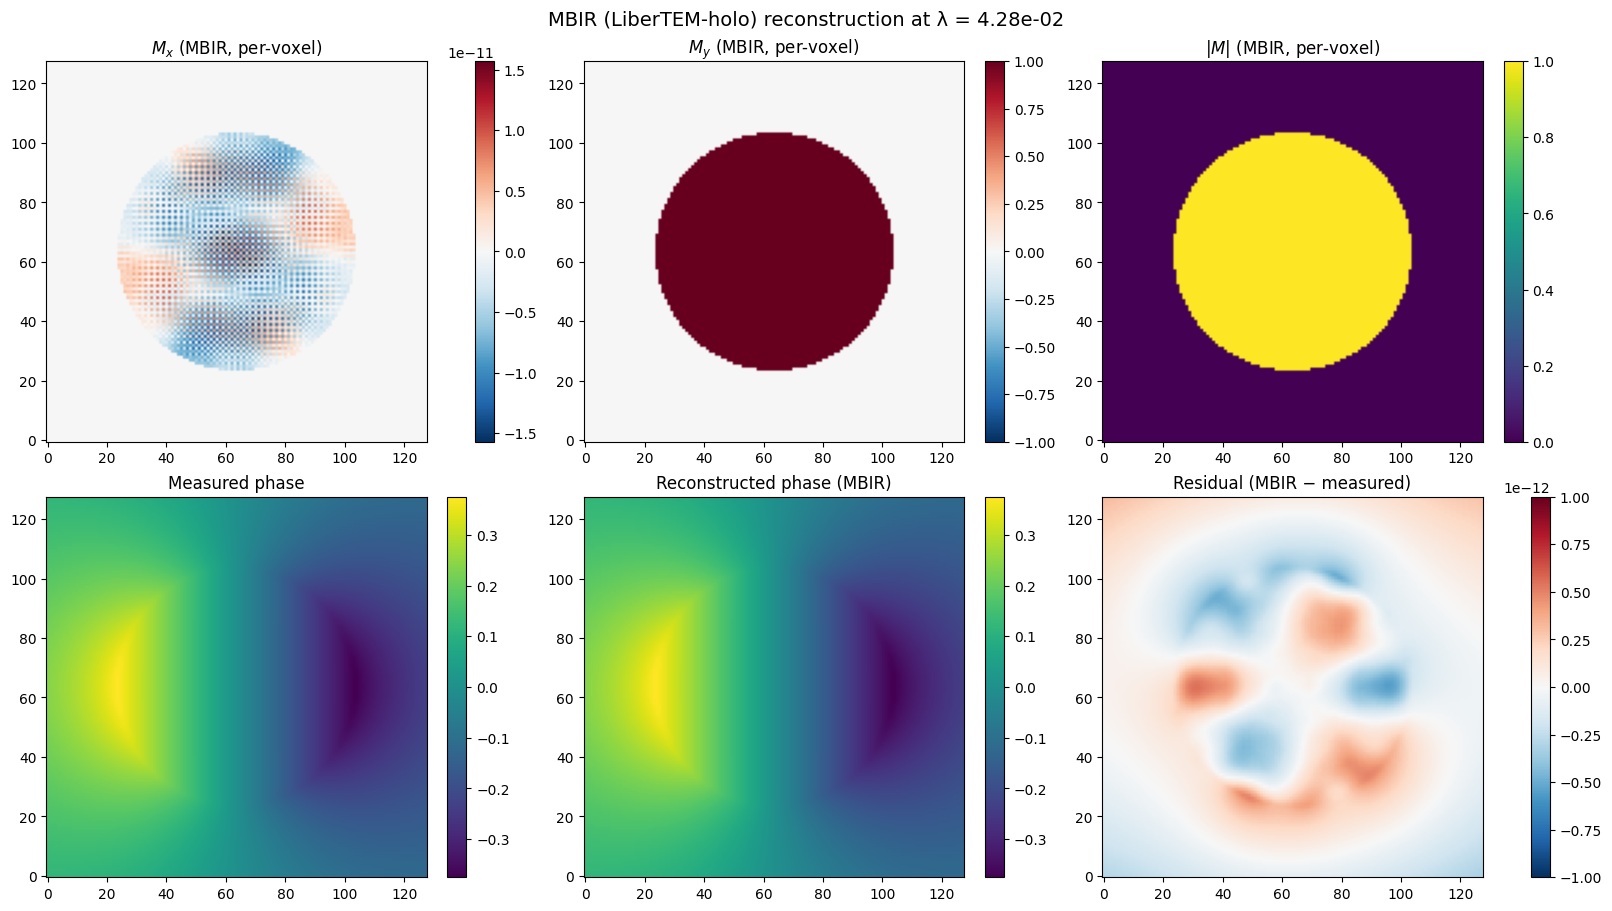

In [36]:
# --- Visualize and compare MBIR and Pyramid reconstructions ---
mx_mbir = np.asarray(best_mag_mbir[..., 0])
my_mbir = np.asarray(best_mag_mbir[..., 1])
mag_norm_mbir = np.sqrt(mx_mbir**2 + my_mbir**2)
pred_mbir = np.asarray(pred_phase_mbir)
residual_mbir = pred_mbir - phase_mag

fig, axs = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

# Row 1: MBIR magnetisation components (already per-voxel thanks to thickness=H)
vmax_mx = max(np.abs(mx_mbir).max(), 1e-12)
vmax_my = max(np.abs(my_mbir).max(), 1e-12)
im = axs[0, 0].imshow(mx_mbir, cmap="RdBu_r", origin="lower", norm=TwoSlopeNorm(0, -vmax_mx, vmax_mx))
axs[0, 0].set_title(r"$M_x$ (MBIR, per-voxel)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)
im = axs[0, 1].imshow(my_mbir, cmap="RdBu_r", origin="lower", norm=TwoSlopeNorm(0, -vmax_my, vmax_my))
axs[0, 1].set_title(r"$M_y$ (MBIR, per-voxel)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)
im = axs[0, 2].imshow(mag_norm_mbir, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (MBIR, per-voxel)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

# Row 2: phase comparison
vmin = min(np.nanmin(phase_mag), np.nanmin(pred_mbir))
vmax = max(np.nanmax(phase_mag), np.nanmax(pred_mbir))
im = axs[1, 0].imshow(phase_mag, cmap="viridis", origin="lower", vmin=vmin, vmax=vmax)
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)
im = axs[1, 1].imshow(pred_mbir, cmap="viridis", origin="lower", vmin=vmin, vmax=vmax)
axs[1, 1].set_title("Reconstructed phase (MBIR)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)
dmax = max(np.abs(residual_mbir).max(), 1e-12)
im = axs[1, 2].imshow(residual_mbir, cmap="RdBu_r", origin="lower", vmin=-dmax, vmax=dmax)
axs[1, 2].set_title("Residual (MBIR − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(f"MBIR (LiberTEM-holo) reconstruction at λ = {best_lam_mbir:.2e}", fontsize=14)
plt.show()